In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_oscura = cv2.imread("imagen_oscura.jpg",  cv2.IMREAD_GRAYSCALE)
img_lavada = cv2.imread("imagen_lavada.jpg",  cv2.IMREAD_GRAYSCALE)

print("Shape imagen oscura:", img_oscura.shape)
print("Shape imagen lavada:", img_lavada.shape)
print("Min/Max imagen oscura:", img_oscura.min(), "/", img_oscura.max())
print("Min/Max imagen lavada:", img_lavada.min(), "/", img_lavada.max())

Shape imagen oscura: (430, 640)
Shape imagen lavada: (430, 640)
Min/Max imagen oscura: 0 / 29
Min/Max imagen lavada: 118 / 177


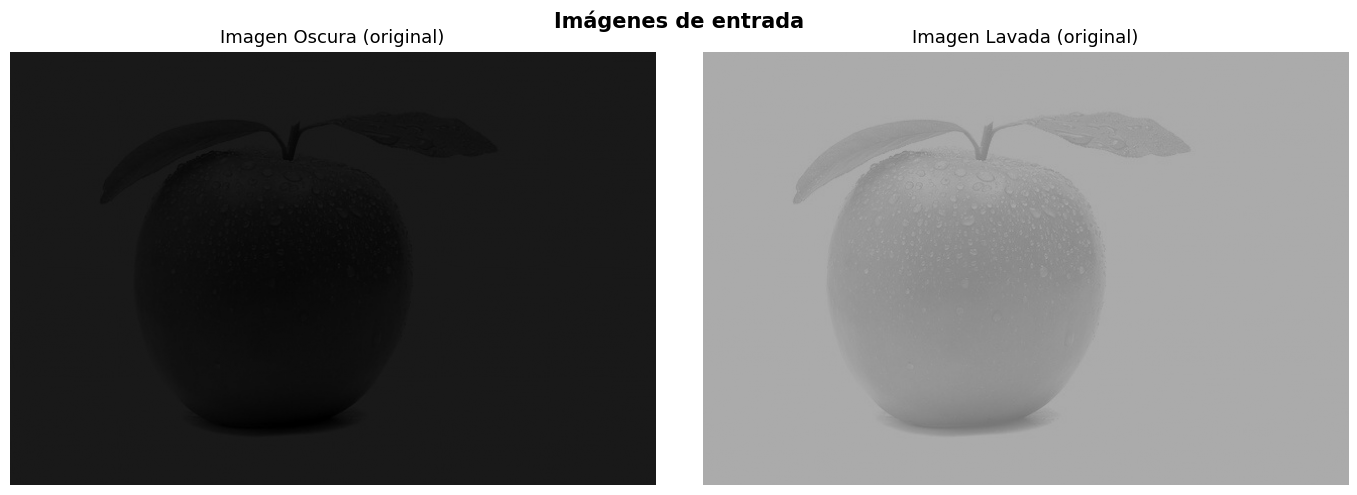

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_oscura, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagen Oscura (original)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_lavada, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Imagen Lavada (original)', fontsize=13)
axes[1].axis('off')

plt.suptitle('Imágenes de entrada', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
img_ecualizada = cv2.equalizeHist(img_oscura)

print("Antes de ecualizar  → Min:", img_oscura.min(),  "Max:", img_oscura.max())
print("Después de ecualizar → Min:", img_ecualizada.min(), "Max:", img_ecualizada.max())

Antes de ecualizar  → Min: 0 Max: 29
Después de ecualizar → Min: 0 Max: 255


/tmp/ipykernel_3525/3584626363.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1][0].hist(img_oscura.ravel(),    256, [0, 256], color='steelblue')
/tmp/ipykernel_3525/3584626363.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1][1].hist(img_ecualizada.ravel(), 256, [0, 256], color='coral')


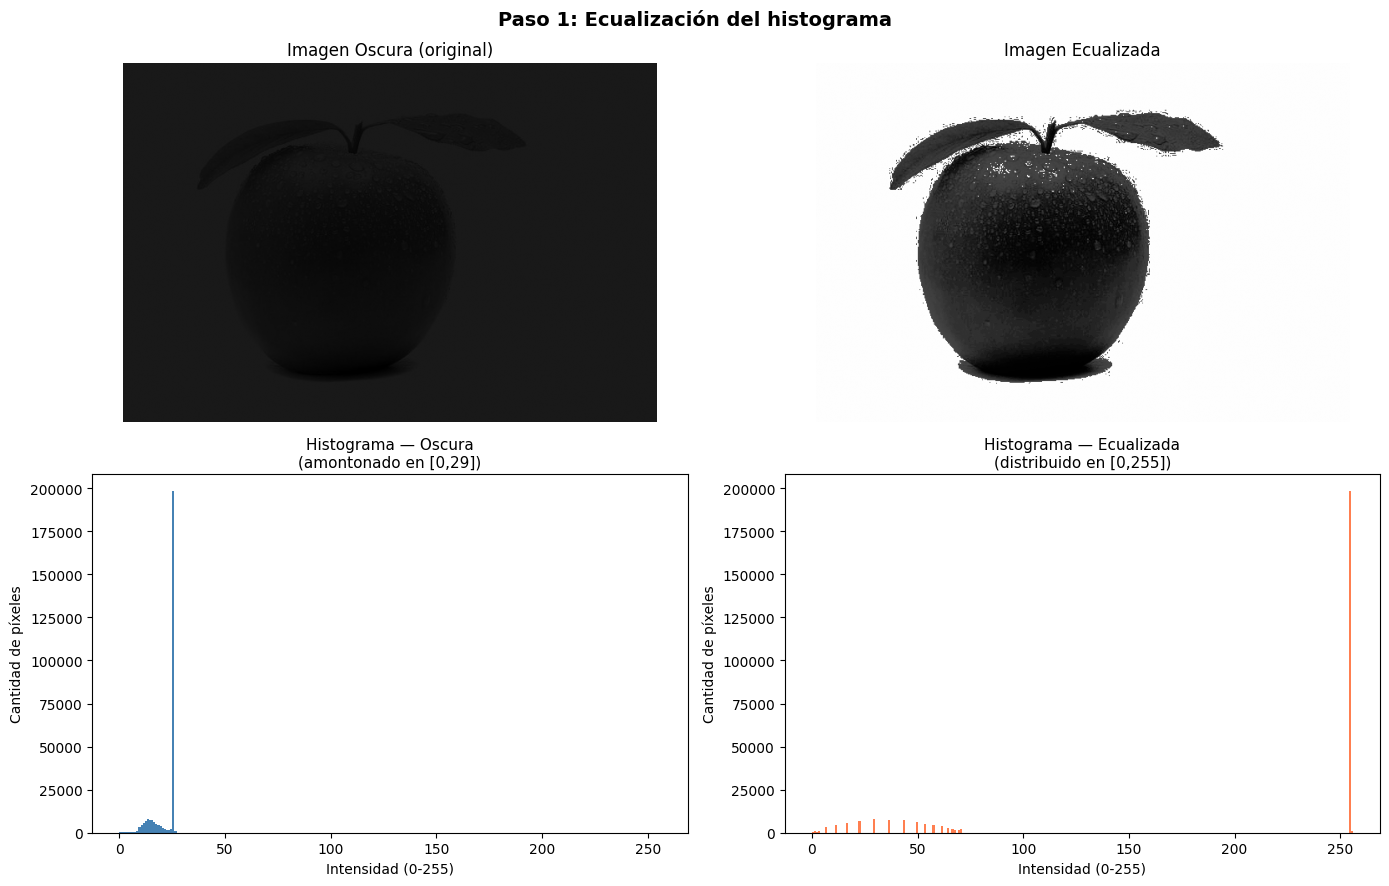


La imagen recuperó contraste: los tonos ahora ocupan todo el rango [0, 255]


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0][0].imshow(img_oscura,    cmap='gray', vmin=0, vmax=255)
axes[0][0].set_title('Imagen Oscura (original)', fontsize=12)
axes[0][0].axis('off')

axes[0][1].imshow(img_ecualizada, cmap='gray', vmin=0, vmax=255)
axes[0][1].set_title('Imagen Ecualizada', fontsize=12)
axes[0][1].axis('off')

# Histogramas
axes[1][0].hist(img_oscura.ravel(),    256, [0, 256], color='steelblue')
axes[1][0].set_title('Histograma — Oscura\n(amontonado en [0,29])', fontsize=11)
axes[1][0].set_xlabel('Intensidad (0-255)')
axes[1][0].set_ylabel('Cantidad de píxeles')

axes[1][1].hist(img_ecualizada.ravel(), 256, [0, 256], color='coral')
axes[1][1].set_title('Histograma — Ecualizada\n(distribuido en [0,255])', fontsize=11)
axes[1][1].set_xlabel('Intensidad (0-255)')
axes[1][1].set_ylabel('Cantidad de píxeles')

plt.suptitle('Paso 1: Ecualización del histograma', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLa imagen recuperó contraste: los tonos ahora ocupan todo el rango [0, 255]")

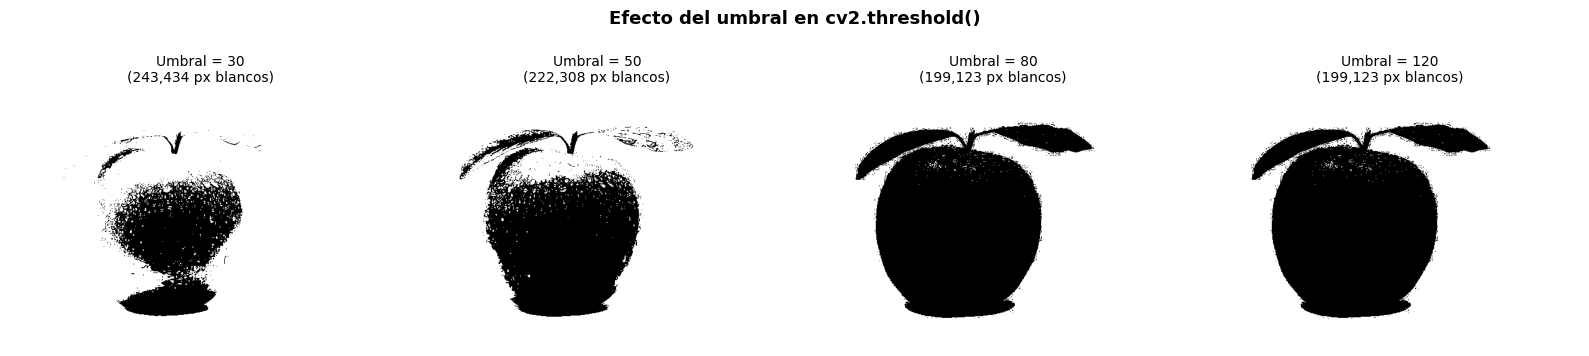

In [5]:
# Exploracion de distintos umbrales
umbrales = [30, 50, 80, 120]

fig, axes = plt.subplots(1, len(umbrales), figsize=(16, 4))

for i, umbral in enumerate(umbrales):
    ret, mask_prueba = cv2.threshold(img_ecualizada, umbral, 255, cv2.THRESH_BINARY)
    pixeles_blancos = np.sum(mask_prueba == 255)
    axes[i].imshow(mask_prueba, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'Umbral = {umbral}\n({pixeles_blancos:,} px blancos)', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Efecto del umbral en cv2.threshold()', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
UMBRAL = 50

ret, mascara_objeto = cv2.threshold(
    img_ecualizada,   # imagen fuente
    UMBRAL,           # umbral de corte
    255,              # valor para píxeles que superan el umbral
    cv2.THRESH_BINARY # tipo: mayor al umbral → 255, menor → 0
)

print(f"Umbral usado: {ret}")
print(f"Píxeles blancos (objeto): {np.sum(mascara_objeto == 255):,}")
print(f"Píxeles negros  (fondo):  {np.sum(mascara_objeto == 0):,}")

Umbral usado: 50.0
Píxeles blancos (objeto): 222,308
Píxeles negros  (fondo):  52,892


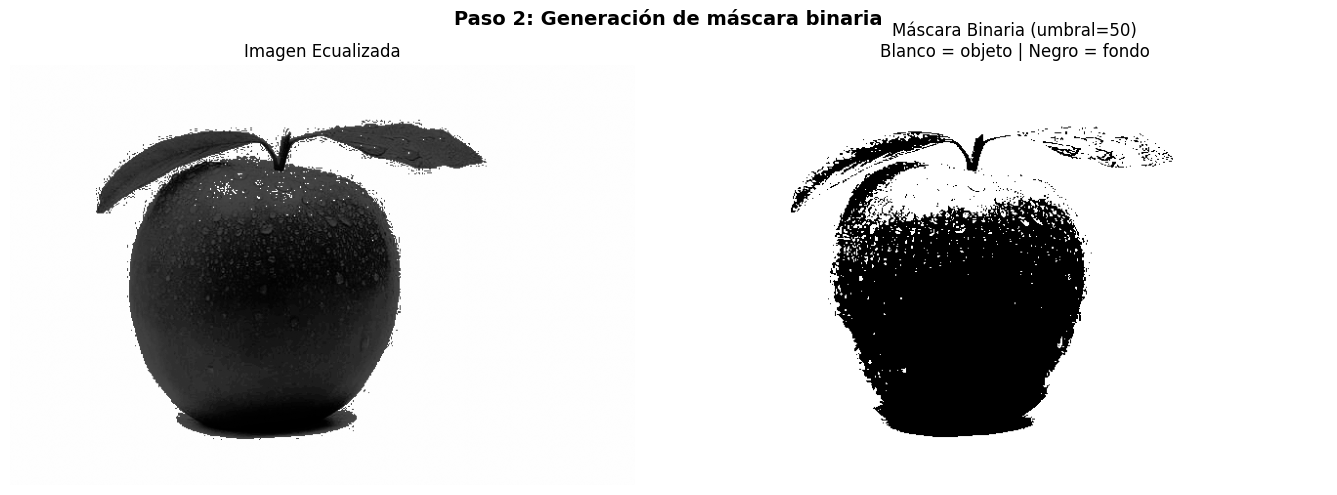


Máscara creada: blanco donde está el objeto, negro donde está el fondo


In [9]:
#Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_ecualizada, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagen Ecualizada', fontsize=12)
axes[0].axis('off')

axes[1].imshow(mascara_objeto, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Máscara Binaria (umbral={UMBRAL})\nBlanco = objeto | Negro = fondo', fontsize=12)
axes[1].axis('off')

plt.suptitle('Paso 2: Generación de máscara binaria', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMáscara creada: blanco donde está el objeto, negro donde está el fondo")

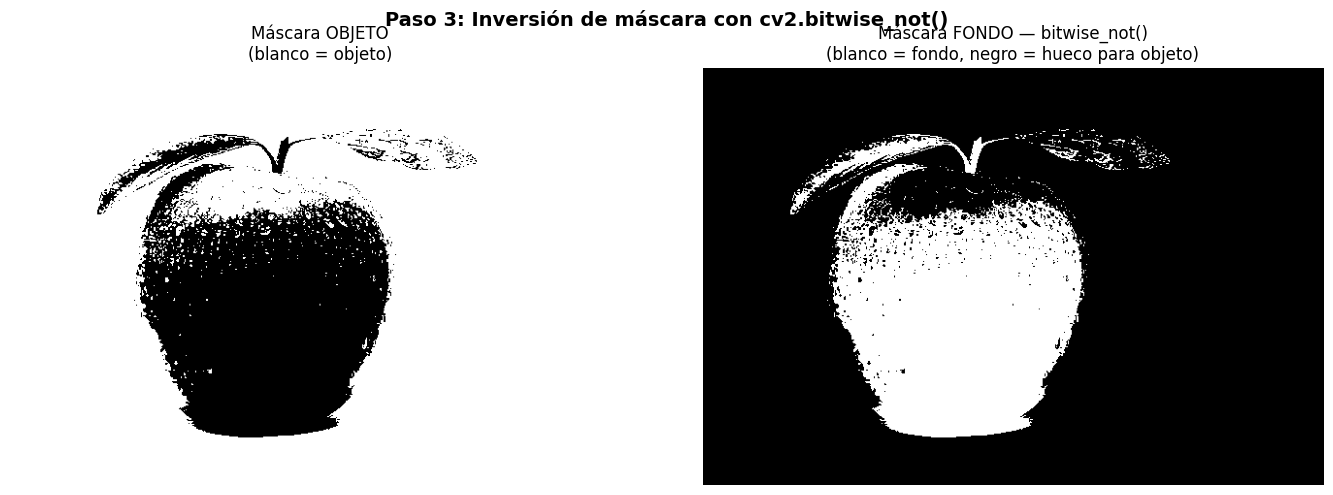


Máscara invertida: ahora podemos usarla para preparar el fondo


In [10]:
mascara_fondo = cv2.bitwise_not(mascara_objeto)

# Visualizar ambas máscaras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(mascara_objeto, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Máscara OBJETO\n(blanco = objeto)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(mascara_fondo, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Máscara FONDO — bitwise_not()\n(blanco = fondo, negro = hueco para objeto)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Paso 3: Inversión de máscara con cv2.bitwise_not()', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMáscara invertida: ahora podemos usarla para preparar el fondo")

In [11]:
objeto_recortado = cv2.bitwise_and(
    img_ecualizada,   # imagen fuente
    img_ecualizada,   # misma imagen (AND consigo misma = copia)
    mask=mascara_objeto  # la máscara decide qué se conserva
)

fondo_preparado = cv2.bitwise_and(
    img_lavada,
    img_lavada,
    mask=mascara_fondo   # máscara invertida: hueco donde va el objeto
)

print("objeto_recortado — Min:", objeto_recortado.min(), "Max:", objeto_recortado.max())
print("fondo_preparado  — Min:", fondo_preparado.min(),  "Max:", fondo_preparado.max())

objeto_recortado — Min: 0 Max: 255
fondo_preparado  — Min: 0 Max: 166


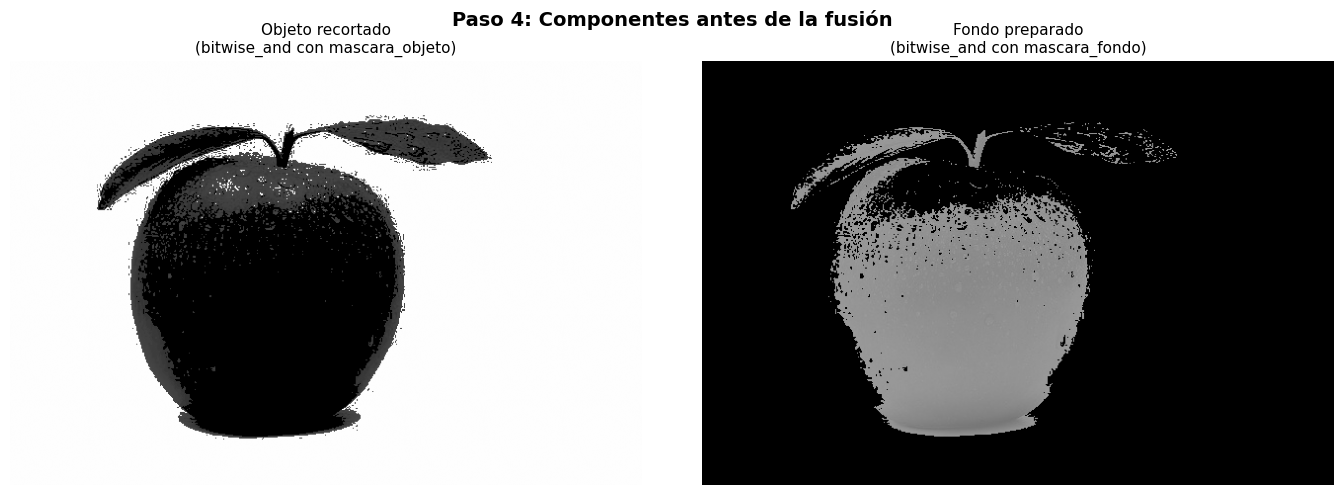

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(objeto_recortado, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Objeto recortado\n(bitwise_and con mascara_objeto)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(fondo_preparado, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Fondo preparado\n(bitwise_and con mascara_fondo)', fontsize=11)
axes[1].axis('off')

plt.suptitle('Paso 4: Componentes antes de la fusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
resultado_final = cv2.add(objeto_recortado, fondo_preparado)

print("Resultado final — Min:", resultado_final.min(), "Max:", resultado_final.max())
print("Shape resultado:", resultado_final.shape)

Resultado final — Min: 53 Max: 255
Shape resultado: (430, 640)


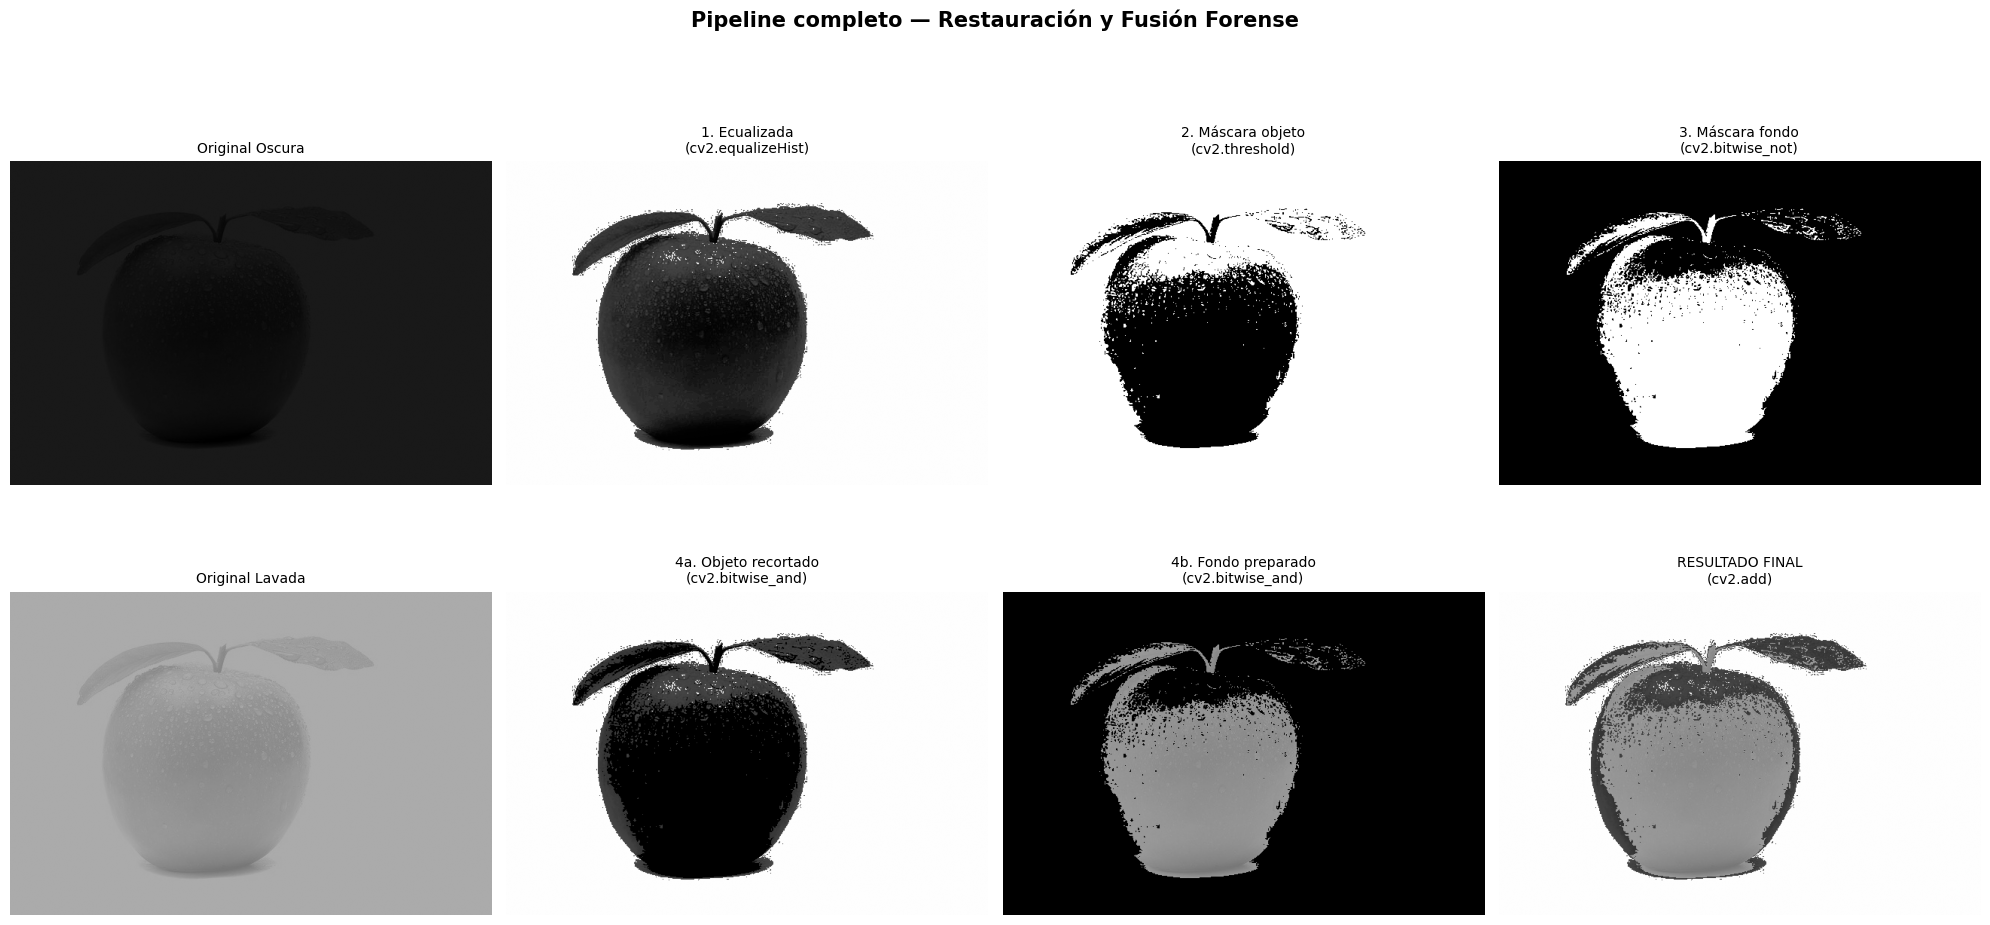

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

imagenes = [
    (img_oscura,        'Original Oscura'),
    (img_ecualizada,    '1. Ecualizada\n(cv2.equalizeHist)'),
    (mascara_objeto,    '2. Máscara objeto\n(cv2.threshold)'),
    (mascara_fondo,     '3. Máscara fondo\n(cv2.bitwise_not)'),
    (img_lavada,        'Original Lavada'),
    (objeto_recortado,  '4a. Objeto recortado\n(cv2.bitwise_and)'),
    (fondo_preparado,   '4b. Fondo preparado\n(cv2.bitwise_and)'),
    (resultado_final,   'RESULTADO FINAL\n(cv2.add)'),
]

for ax, (img, titulo) in zip(axes.ravel(), imagenes):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(titulo, fontsize=10, pad=6)
    ax.axis('off')

plt.suptitle('Pipeline completo — Restauración y Fusión Forense', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3525/1307566721.py:16: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


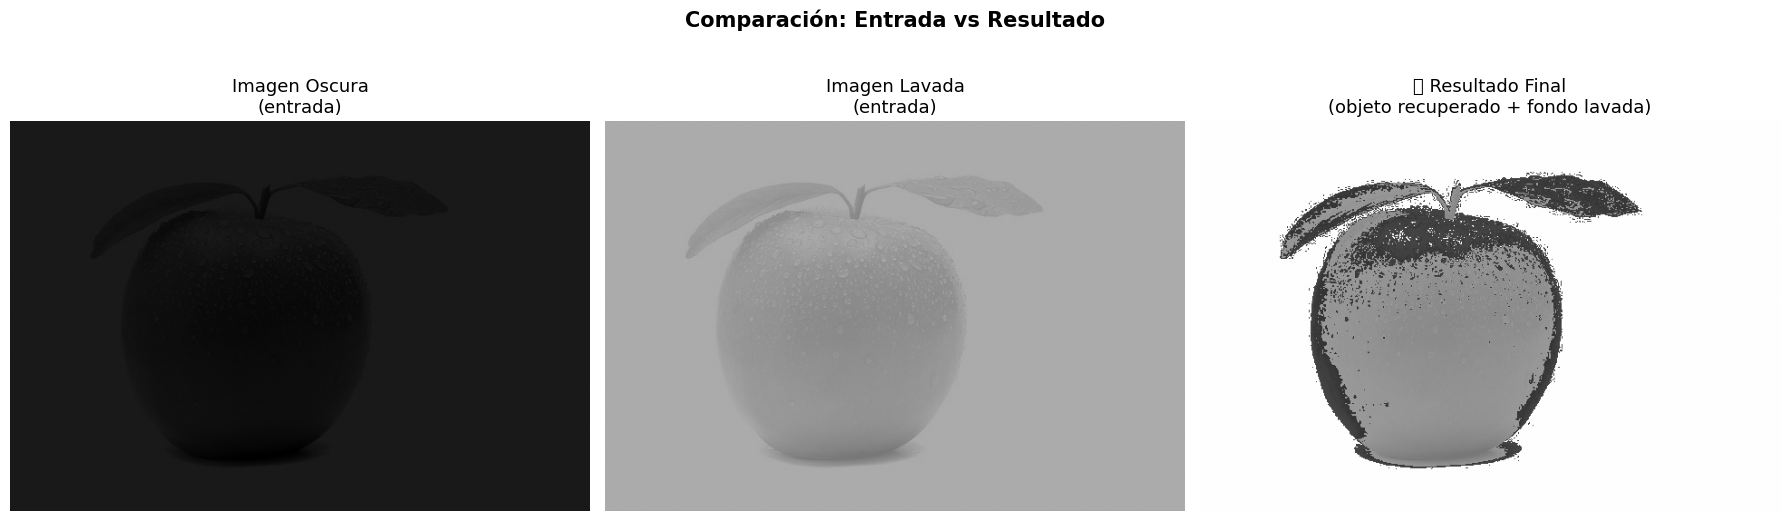

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_oscura,    cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagen Oscura\n(entrada)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_lavada,    cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Imagen Lavada\n(entrada)', fontsize=13)
axes[1].axis('off')

axes[2].imshow(resultado_final, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('✅ Resultado Final\n(objeto recuperado + fondo lavada)', fontsize=13)
axes[2].axis('off')

plt.suptitle('Comparación: Entrada vs Resultado', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()